In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
import sys

sys.path.insert(0, "../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'

In [3]:
f = open(f"data/{NUTS0}_WNV_{NUTS2}_cases_dates.txt", "r")
print(f.read())

months: 7, 8, 9, 10, 
years: 2010, 2011, 2018, 2019, 2020, 


In [4]:
r_u = 0.05
near_u = 0.25
smote = 1
scaler = 'minmax'
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
path = f'data/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv'

In [5]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.77356,39.67760,2010-01-01,θεσσαλιας,αγιας,22,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,661.8,10705.0,17.3,45.74874,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.267143,16.284286,8.25,11.242240,5.302469,9.587946,4.419169,16.775915,6.090496,19.523378,8.155853,22.057143,52.814286,0.0,9517.677436,442.116743,6,215.239966,132.347263,181.430575,0.0,40.243238,31,89,30,89.0,30,89,10,10,1,6,6,2,0,55,0,0
1,22.69493,39.10844,2010-01-01,θεσσαλιας,αλμυρου,6,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,905.4,16004.0,20.6,45.21648,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.082222,16.254444,11.91,9.896909,4.265526,10.677746,3.618618,17.039068,5.650136,20.541023,7.613520,13.700000,31.211111,0.3,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,21,78,20,78.0,20,78,8,8,4,1,1,2,0,41,0,0
2,23.91189,39.20320,2010-01-01,θεσσαλιας,αλοννησου,24,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,129.6,3153.0,21.2,45.92025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.640000,17.470000,11.81,12.687143,9.572857,11.814615,7.350000,14.911538,8.634000,17.832609,10.427500,62.200000,98.600000,0.0,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,93,20,93.0,20,93,8,8,4,1,1,2,0,24,0,0
3,21.43052,39.25731,2010-01-01,θεσσαλιας,αργιθεας,0,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,372.9,3515.0,9.3,44.72587,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.565556,0.587778,5.773333,-1.428201,13.292222,2.807245,18.730554,6.231131,47.133333,88.466667,22.1,19327.278832,1925.318354,27,284.268894,1127.254453,234.678996,0.0,1.719393,22,71,20,71.0,20,71,9,9,4,1,1,2,0,94,0,0
4,22.93792,39.41186,2010-01-01,θεσσαλιας,βολου,14,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,385.6,138865.0,374.6,45.60091,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.356667,NaN,12.845119,5.105833,12.089515,3.862547,17.407709,6.368088,21.703833,8.805092,30.066667,48.733333,0.0,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,95,30,95.0,30,95,10,10,1,6,6,2,0,34,0,0


In [6]:
dataset = dataset.query('month >= 6 & month <= 10')
dataset.reset_index(inplace=True, drop=True)

In [7]:
dataset

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.77356,39.67760,2010-06-01,θεσσαλιας,αγιας,22,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,661.8,10705.00,17.3,45.74874,0.603001,0.265313,-0.301741,-0.265313,0.573894,0.245601,-0.311559,-0.245601,0.045817,0.040099,0.031587,0.040099,18.948571,25.267143,12.630000,11.242240,5.302469,9.587946,4.419169,16.775915,6.090496,19.523378,8.155853,9.914286,48.814286,276.085714,9517.677436,442.116743,6,215.239966,132.347263,181.430575,0.0,40.243238,31,89,30,89.0,30,89,10,10,1,6,6,2,0,13,33,0
1,22.69493,39.10844,2010-06-01,θεσσαλιας,αλμυρου,6,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,905.4,16004.00,20.6,45.21648,0.479493,0.178157,-0.298480,-0.178157,0.463172,0.181917,-0.256714,-0.181917,0.049810,0.056481,0.042878,0.056481,21.074444,27.592222,14.556667,9.896909,4.265526,10.677746,3.618618,17.039068,5.650136,20.541023,7.613520,7.744444,38.488889,258.088889,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,21,78,20,78.0,20,78,8,8,4,1,1,2,0,10,25,0
2,23.91189,39.20320,2010-06-01,θεσσαλιας,αλοννησου,24,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,129.6,3153.00,21.2,45.92025,0.482904,0.101375,-0.377909,-0.101375,0.511274,0.141458,-0.348274,-0.141458,0.060422,0.073490,0.033599,0.073490,21.110000,23.570000,18.650000,12.687143,9.572857,11.814615,7.350000,14.911538,8.634000,17.832609,10.427500,52.500000,112.500000,434.600000,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,93,20,93.0,20,93,8,8,4,1,1,2,0,11,23,0
3,21.43052,39.25731,2010-06-01,θεσσαλιας,αργιθεας,0,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,372.9,3515.00,9.3,44.72587,0.572977,0.250193,-0.265649,-0.250193,0.556914,0.239964,-0.261899,-0.239964,0.034064,0.033821,0.019310,0.033821,17.113333,24.050000,10.176667,-1.565556,0.587778,5.773333,-1.428201,13.292222,2.807245,18.730554,6.231131,1.700000,23.933333,521.333333,19327.278832,1925.318354,27,284.268894,1127.254453,234.678996,0.0,1.719393,22,71,20,71.0,20,71,9,9,4,1,1,2,0,30,58,0
4,22.93792,39.41186,2010-06-01,θεσσαλιας,βολου,14,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,385.6,138865.00,374.6,45.60091,0.396016,0.175898,-0.176754,-0.175898,0.379949,0.174997,-0.170381,-0.174997,0.044764,0.046550,0.020831,0.046550,20.613333,27.036667,14.190000,12.845119,5.105833,12.089515,3.862547,17.407709,6.368088,21.703833,8.805092,5.866667,49.233333,280.266667,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,95,30,95.0,30,95,10,10,1,6,6,2,0,13,23,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3031,22.53916,39.85570,2021-10-16,θεσσαλιας,τεμπων,23,16,10,41,2021,-0.101168,-0.994869,-8.660254e-01,0.5,-0.989040,0.147647,576.7,11.99,23.8,45.78745,0.463004,0.114608,-0.413858,-0.114608,0.505659,0.148993,-0.449337,-0.148993,0.068648,0.086893,0.047306,0.086893,21.700000,28.770000,14.630000,5.024958,-0.289957,10.961907,4.191315,12.818548,2.085360,18.921745,4.801424,90.220000,120.

In [8]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,244,9,253,8.33%
1,2011,227,30,257,8.47%
2,2012,250,0,250,8.23%
3,2013,250,0,250,8.23%
4,2014,250,0,250,8.23%
5,2015,250,0,250,8.23%
6,2016,250,0,250,8.23%
7,2017,250,0,250,8.23%
8,2018,245,7,252,8.30%
9,2019,220,53,273,8.99%


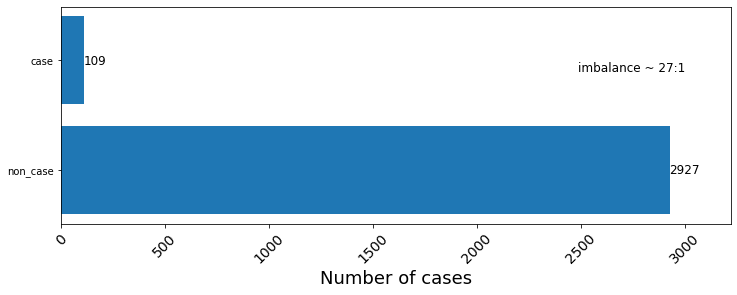

In [9]:
plot_imbalance(dataset)

In [10]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns

In [11]:
for train_idx, test_idx in yearCV_split(dataset):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_train = data_train['case']
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_test = data_test['case']
    
    X_train, X_test, y_train, y_test, X_train_df = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    
    w0,w1 = calculate_weights(y_train)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    
    train, test, coef = train_and_predict(model, X_train_df, data_test, X_train, y_train, X_test, y_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    coefficients.append(coef)
    
    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

Year: 2010 || w0:1, w1:11 || ##
Year: 2011 || w0:1, w1:13 || ##
Year: 2012 || w0:1, w1:10 || ##
Year: 2013 || w0:1, w1:10 || ##
Year: 2014 || w0:1, w1:10 || ##
Year: 2015 || w0:1, w1:10 || ##
Year: 2016 || w0:1, w1:10 || ##
Year: 2017 || w0:1, w1:10 || ##
Year: 2018 || w0:1, w1:10 || ##
Year: 2019 || w0:1, w1:19 || ##
Year: 2020 || w0:1, w1:11 || ##
Year: 2021 || w0:1, w1:10 || ##


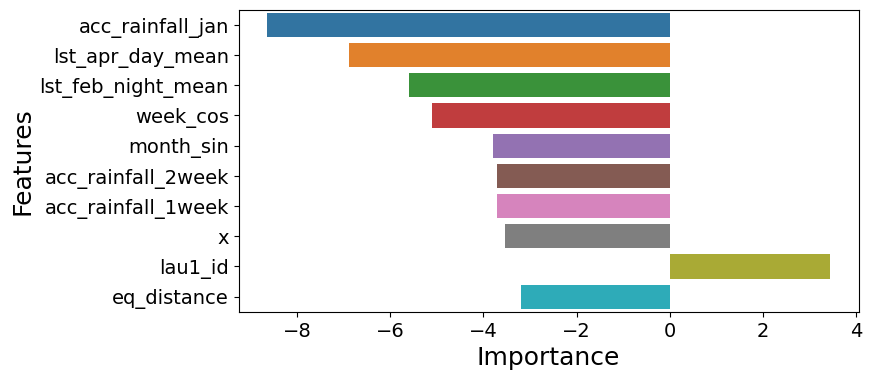

In [12]:
plot_feature_importance(coefficients, feature_names, top = 10, figure_size = (8, 4))

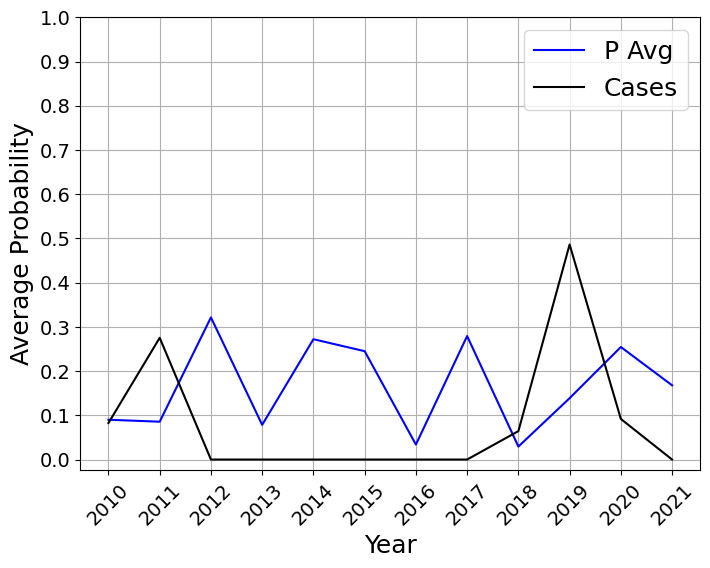

In [13]:
plot_trend_curve(results_test, list(dsc['case']))

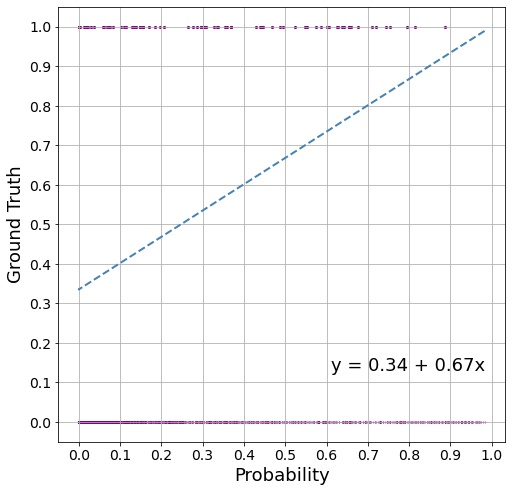

In [14]:
plot_probability_curve(results_test)

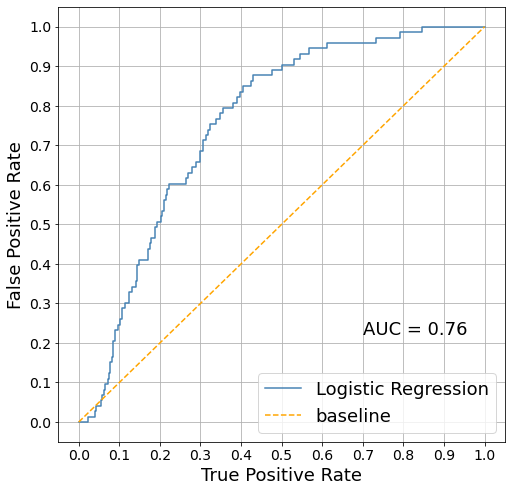

In [15]:
plot_roc_curve(results_test)

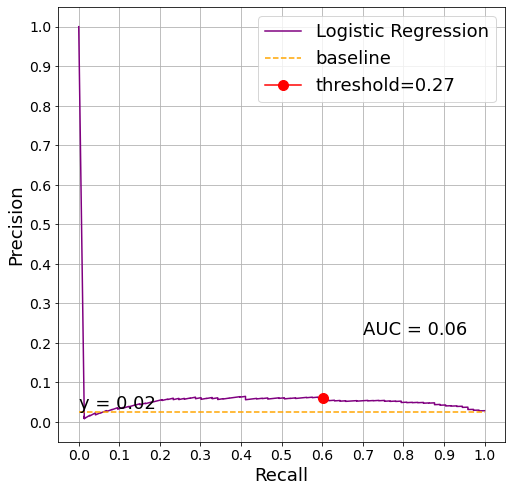

In [16]:
plot_pr_curve(results_test, plot_fbeta = True)

In [17]:
operational, cumulative, avg, weighted = evaluate_operational(results_test, k = 5, prob_threshold = -1)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')

Average: 74.79%
Weighted Average: 68.81%


In [18]:
operational

,Prediction Date,Infected,Discovered,Out of,Percentage,percentage
0,01/06/2010,0,0,0,NaN,NaN
1,16/06/2010,0,0,0,NaN,NaN
2,01/07/2010,0,0,0,NaN,NaN
3,16/07/2010,1,0,1,0.00 %,0.0
4,01/08/2010,1,1,1,100.00 %,1.0
...,...,...,...,...,...,...
115,16/08/2021,0,0,0,NaN,NaN
116,01/09/2021,0,0,0,NaN,NaN
117,16/09/2021,0,0,0,NaN,NaN
118,01/10/2021,0,0,0,NaN,NaN


In [19]:
cumulative

,Year,Infected,Discovered,Out Of,Percentage,percentage
0,2010,6,5,6,83.33 %,0.8333
1,2011,23,8,19,42.11 %,0.4211
2,2012,0,0,0,nan %,NaN
3,2013,0,0,0,nan %,NaN
4,2014,0,0,0,nan %,NaN
5,2015,0,0,0,nan %,NaN
6,2016,0,0,0,nan %,NaN
7,2017,0,0,0,nan %,NaN
8,2018,5,5,5,100.00 %,1.0000
9,2019,30,18,22,81.82 %,0.8182


In [20]:
report_train, report_test = classification_report(results_train, results_test, threshold = 0.2, beta = 4)

In [21]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2010,6.0000,0.1520,0.8490,0.1316,0.8333,0.6343,0.1176
1,2011,23.0000,0.1520,0.6557,0.2632,0.4348,0.4187,0.2571
2,2012,0.0000,0.4880,0.5120,0.0000,0.0000,0.0000,0.6609
3,2013,0.0000,0.1400,0.8600,0.0000,0.0000,0.0000,0.0946
4,2014,0.0000,0.4280,0.5720,0.0000,0.0000,0.0000,0.4852
5,2015,0.0000,0.4040,0.5960,0.0000,0.0000,0.0000,0.4447
6,2016,0.0000,0.0520,0.9480,0.0000,0.0000,0.0000,0.0390
7,2017,0.0000,0.4760,0.5240,0.0000,0.0000,0.0000,0.4701
8,2018,5.0000,0.0320,0.4837,0.0000,0.0000,0.0000,0.1085
9,2019,30.0000,0.2280,0.7871,0.3860,0.7333,0.6965,0.2854
